<a href="https://colab.research.google.com/github/gandhias-a11y/colab/blob/main/lab09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CH3 Group Comparisons

In [ ]:
import pandas as pd
mlb=pd.read_csv('mlb.csv')
print(mlb.head())
print(mlb.shape)

              name team       position  height  weight    age
0    Adam_Donachie  BAL        Catcher      74   180.0  22.99
1        Paul_Bako  BAL        Catcher      74   215.0  34.69
2  Ramon_Hernandez  BAL        Catcher      72   210.0  30.78
3     Kevin_Millar  BAL  First_Baseman      72   210.0  35.43
4      Chris_Gomez  BAL  First_Baseman      73   188.0  35.71
(1034, 6)


In [ ]:
print(mlb.describe())

            height       weight          age
count  1034.000000  1033.000000  1034.000000
mean     73.697292   201.689255    28.736712
std       2.305818    20.991491     4.320310
min      67.000000   150.000000    20.900000
25%      72.000000   187.000000    25.440000
50%      74.000000   200.000000    27.925000
75%      75.000000   215.000000    31.232500
max      83.000000   290.000000    48.520000


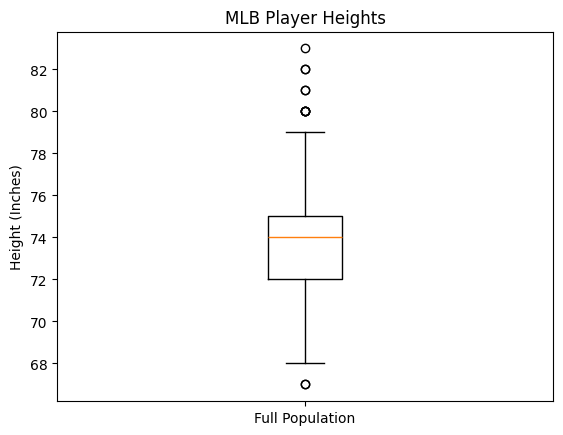

In [ ]:
import matplotlib.pyplot as plt
fig1, ax1 = plt.subplots()
ax1.boxplot([mlb['height']])
ax1.set_ylabel('Height (Inches)')
plt.title('MLB Player Heights')
plt.xticks([1], ['Full Population'])
plt.show()

In [ ]:
sample1=mlb.sample(n=30,random_state=8675309)
sample2=mlb.sample(n=30,random_state=1729)

sample3=[71, 72, 73, 74, 74, 76, 75, 75, 75, 76, 75, 77, 76, 75, 77, 76, 75,\
76, 76, 75, 75, 81,77, 75, 77, 75, 77, 77, 75, 75]

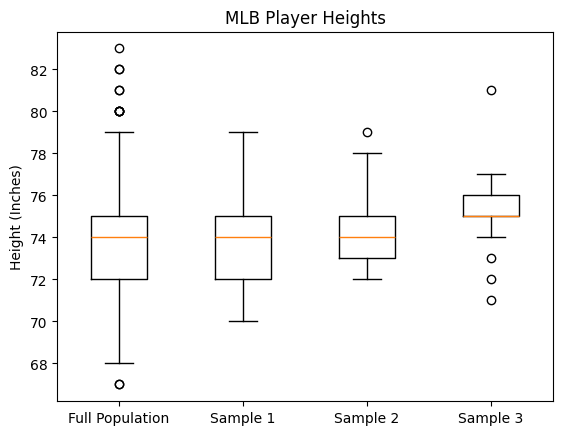

In [ ]:
import numpy as np
fig1, ax1 = plt.subplots()
ax1.boxplot([mlb['height'],sample1['height'],sample2['height'],np.array(sample3)])
ax1.set_ylabel('Height (Inches)')
plt.title('MLB Player Heights')
plt.xticks([1,2,3,4], ['Full Population','Sample 1','Sample 2','Sample 3'])
plt.show()

In [ ]:
print(np.mean(sample1['height']))
print(np.mean(sample2['height']))
print(np.mean(sample3))

73.8
74.36666666666666
75.43333333333334


In [ ]:
alldifferences=[]
for i in range(1000):
 newsample1=mlb.sample(n=30,random_state=i*2)
 newsample2=mlb.sample(n=30,random_state=i*2+1)
 alldifferences.append(newsample1['height'].mean()-newsample2['height'].mean())
print(alldifferences[0:10])

[np.float64(0.8333333333333286), np.float64(-0.30000000000001137), np.float64(-0.10000000000000853), np.float64(-0.1666666666666572), np.float64(0.06666666666667709), np.float64(-0.9666666666666686), np.float64(0.7999999999999972), np.float64(0.9333333333333371), np.float64(-0.5333333333333314), np.float64(-0.20000000000000284)]


/tmp/ipykernel_662/2366243221.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(alldifferences).set_title("Differences Between Sample Means")


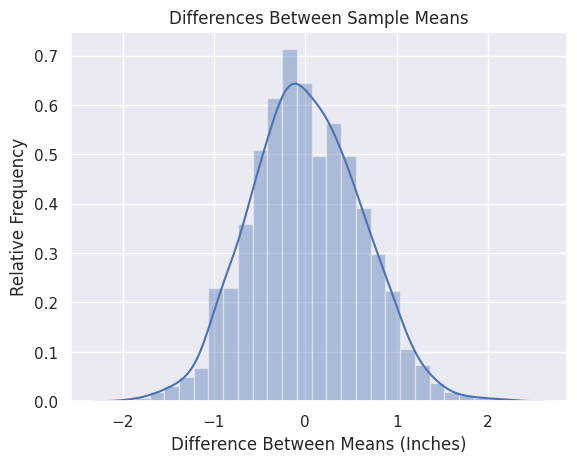

In [ ]:
import seaborn as sns
sns.set()
ax=sns.distplot(alldifferences).set_title("Differences Between Sample Means")
plt.xlabel('Difference Between Means (Inches)')
plt.ylabel('Relative Frequency')
plt.show()

In [ ]:
largedifferences=[diff for diff in alldifferences if abs(diff)>=1.6]
print(len(largedifferences))

smalldifferences=[diff for diff in alldifferences if abs(diff)>=0.6]
print(len(smalldifferences))

8
314


In [ ]:
import scipy.stats
scipy.stats.ttest_ind(sample1['height'],sample2['height'])

TtestResult(statistic=np.float64(-1.0839563860213952), pvalue=np.float64(0.2828695892305152), df=np.float64(58.0))

In [ ]:
scipy.stats.mannwhitneyu(sample1['height'],sample2['height'])

MannwhitneyuResult(statistic=np.float64(392.0), pvalue=np.float64(0.38913738408151577))

In [ ]:
desktop=pd.read_csv('desktop.csv')
laptop=pd.read_csv('laptop.csv')

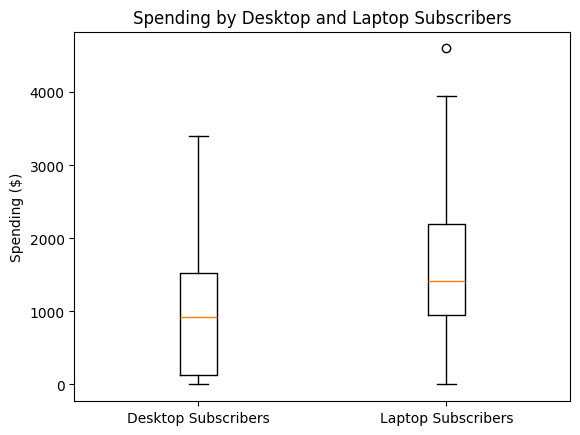

In [ ]:
sns.reset_orig()
fig1, ax1 = plt.subplots()
ax1.set_title('Spending by Desktop and Laptop Subscribers')
ax1.boxplot([desktop['spending'].values,laptop['spending'].values])
ax1.set_ylabel('Spending ($)')
plt.xticks([1,2], ['Desktop Subscribers','Laptop Subscribers'])
plt.show()

In [ ]:
print(np.mean(desktop['age']))
print(np.mean(laptop['age']))
print(np.median(desktop['age']))
print(np.median(laptop['age']))
print(np.quantile(laptop['spending'],.25))
print(np.quantile(desktop['spending'],.75))
print(np.std(desktop['age']))

35.766666666666666
38.733333333333334
32.0
33.0
957.5
1528.25
14.943634839697543


In [ ]:
scipy.stats.ttest_ind(desktop['spending'],laptop['spending'])

TtestResult(statistic=np.float64(-2.109853741030508), pvalue=np.float64(0.03919630411621095), df=np.float64(58.0))

Ch3 summary:
This chapter focuses on how to make meaningful comparisons between two datasets. While we begin by comparing basic descriptive statistics (mean, max, min, etc.), we later turn to tests that help determine whether two samples are statistically significantly different from one another.

We start we basic summary stats of the dataset as a whole, but we then create two samples by randomlyl selecting 30 of the players to be in each one. We also manually create a sample by typing in random numbers. Next, we perform some basic comparisons between the three samples and the total population through boxplots and an analysis of the differences.

We now move on to hypothesis testing. The chapter walks through the steps of a t-test: the creation of the two hypotheses, the chosen significance level, and the calculation of the p-value. Our chosen topic for the test is whether samples 1 and 3 are random samples from the same population. Ultimately, we do not reject our null hypothesis and we determine that it is possible that samples 1 and 3 are from the same population. The book then discusses different types of hypothesis testing and explains the nuances behind them.

Now, the chapter switches to a business-based set of data to analyze. Similarly to the first half of the chapter, we start off by doing basic descriptive stats and creating boxplots. We then conduct a hypothesis test, just like before, to see whether the two samples come from the same population. Since the resulting p-value is less than 0.05, we can reject the null hypothesis and say that it is likely the two samples are not from the same population. The practical inference from this result is that the users of the two different samples are different enough to not have the same marketing tactics used for both products.
